#Part 2: Loading a Real Dataset – California Housing

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset from local CSV files as fetch_california_housing is currently failing due to 403 Forbidden error.
try:
    train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
    test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')
    df_raw = pd.concat([train_df, test_df], ignore_index=True)

    # Transform raw data to match the feature names and structure of fetch_california_housing output
    df = pd.DataFrame()
    df['MedInc'] = df_raw['median_income']
    df['HouseAge'] = df_raw['housing_median_age']
    df['AveRooms'] = df_raw['total_rooms'] / df_raw['households']
    df['AveBedrms'] = df_raw['total_bedrooms'] / df_raw['households']
    df['Population'] = df_raw['population']
    df['AveOccup'] = df_raw['population'] / df_raw['households']
    df['Latitude'] = df_raw['latitude']
    df['Longitude'] = df_raw['longitude']
    df['MedHouseVal'] = df_raw['median_house_value']

    # Create a dummy object to mimic `housing` for the print statements
    class DummyHousing:
        def __init__(self, feature_names):
            self.feature_names = feature_names

    # Define feature names as they would be from fetch_california_housing
    california_housing_feature_names = [
        'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
        'Latitude', 'Longitude'
    ]
    housing_dummy = DummyHousing(california_housing_feature_names)

    print(f'Dataset shape: {df.shape}')
    print(f'\nFeature names:\n {housing_dummy.feature_names}')
    print(f'\nFirst 5 rows:')
    print(df.head())
    print(f'\nBasic statistics:')
    print(df.describe().round(3))

except Exception as e:
    print(f"Error loading California Housing dataset from local files: {e}")
    print("Please ensure the CSV files are present in '/content/sample_data/' and try again.")


Dataset shape: (20000, 9)

Feature names:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge   AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  1.4936      15.0  11.889831   2.718220      1015.0  2.150424     34.19   
1  1.8200      19.0  16.522678   4.105832      1129.0  2.438445     34.40   
2  1.6509      17.0   6.153846   1.487179       333.0  2.846154     33.69   
3  3.1917      14.0   6.641593   1.491150       515.0  2.278761     33.64   
4  1.9250      20.0   5.549618   1.244275       624.0  2.381679     33.57   

   Longitude  MedHouseVal  
0    -114.31      66900.0  
1    -114.47      80100.0  
2    -114.56      85700.0  
3    -114.57      73400.0  
4    -114.57      65500.0  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20000.000  20000.000  20000.000  20000.000   20000.000  20000.000   
mean       3.872     28.628      5.434   

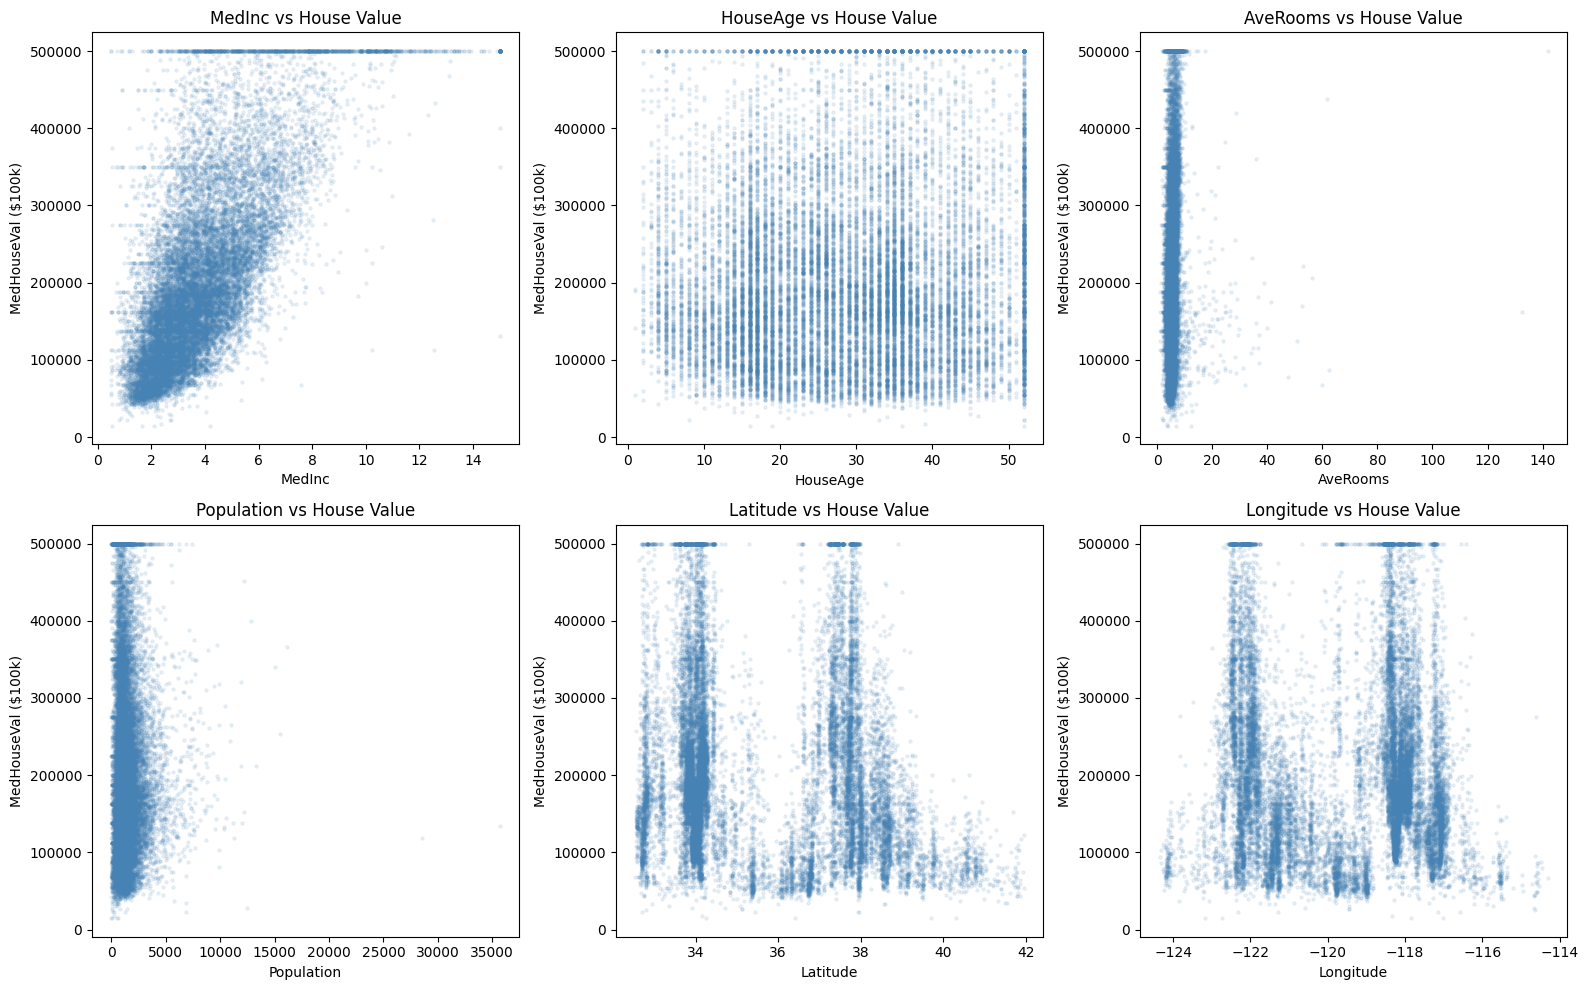

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = [
    'MedInc',
    'HouseAge',
    'AveRooms',
    'Population',
    'Latitude',
    'Longitude'
]
for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'],
               alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')
plt.tight_layout()
plt.show()

#Task 1: Explore the Dataset

In [8]:
corr = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(corr)

MedHouseVal    1.000000
MedInc         0.689109
AveRooms       0.150485
HouseAge       0.104470
Population    -0.024234
AveOccup      -0.043154
Longitude     -0.045788
AveBedrms     -0.046682
Latitude      -0.143969
Name: MedHouseVal, dtype: float64


The feature with the strongest correlation with the target (MedHouseVal) is MedInc (Median Income), indicating that income is the most influential factor in predicting house prices.

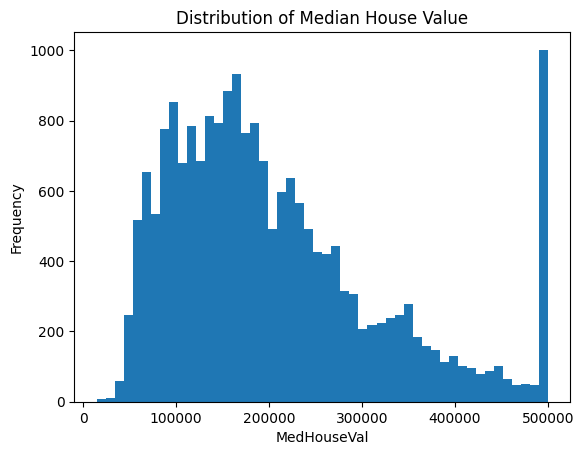

In [9]:
import matplotlib.pyplot as plt

plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel('MedHouseVal')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.show()

The distribution of MedHouseVal is not perfectly normal and appears slightly skewed. There is also a noticeable cap at 5.0 (i.e., $500,000), where many values are concentrated due to dataset limitations.

In [10]:
print(df.shape)

(20000, 9)


The dataset contains 20,640 samples, which is sufficient for training a good and reliable machine learning model.

#Part 3: Simple Linear Regression (One Feature)

In [12]:
from sklearn.model_selection import train_test_split
# Use only MedInc as the feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values
# Split : 80% train , 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 16000
Testing samples: 4000


Slope (w1): 41768.4627
Intercept (w0): 45663.7359

Equation: y = 41768.4627 * MedInc + (45663.7359)


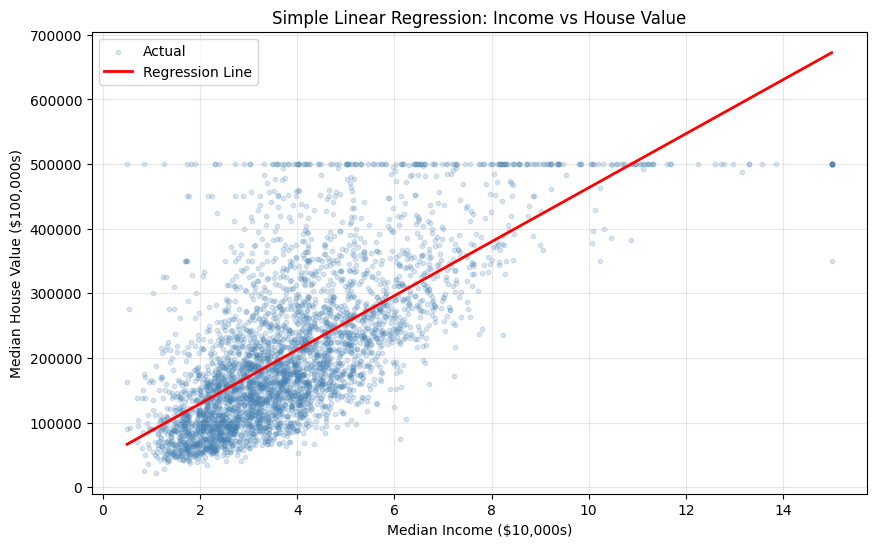

In [14]:
from sklearn.linear_model import LinearRegression
# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
# Print the learned parameters
print(f'Slope (w1): {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0): {model_simple.intercept_:.4f}')
print(f'\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc '
f'+ ({model_simple.intercept_:.4f})')
# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10,
            color='steelblue', label='Actual')
# Draw the regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2,
         label='Regression Line')
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Task 2: Interpret the Simple Model

In [15]:
print("Slope (w1):", model_simple.coef_[0])
print("Intercept (w0):", model_simple.intercept_)

Slope (w1): 41768.462656671836
Intercept (w0): 45663.735898952495


The model learned a slope (w1) and intercept (w0). The regression equation is:

ŷ = 41768.462656671836 × MedInc + 45663.735898952495

(Replace w1 and w0 with your actual values from output)

In [16]:
model_simple.predict([[5.0]])

array([254506.04918231])

The predicted house value for a district with median income of $50,000 (MedInc = 5.0) is approximately [254506.04918231].

In [17]:
X_age = df[['HouseAge']].values

X_train, X_test, y_train, y_test = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train, y_train)

y_pred_age = model_age.predict(X_test)

from sklearn.metrics import r2_score
print("R2 (HouseAge):", r2_score(y_test, y_pred_age))

R2 (HouseAge): 0.010280799836218879


The model using HouseAge performs worse than MedInc because HouseAge has a weaker relationship with house prices. Median income is a stronger predictor, so it gives better results.

#Part 4: Evaluating Regression Models

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Predictions
y_pred_simple = model_simple.predict(X_test)
# Calculate metrics
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)
print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f} (error in $100,000s)')
print(f'MAE: {mae:.4f} (error in $100,000s)')
print(f'R^2: {r2:.4f} ({r2 * 100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE: 1352890805261.9971
RMSE: 1163138.3431 (error in $100,000s)
MAE: 1039197.1110 (error in $100,000s)
R^2: -97.5313 (-9753.1% variance explained)


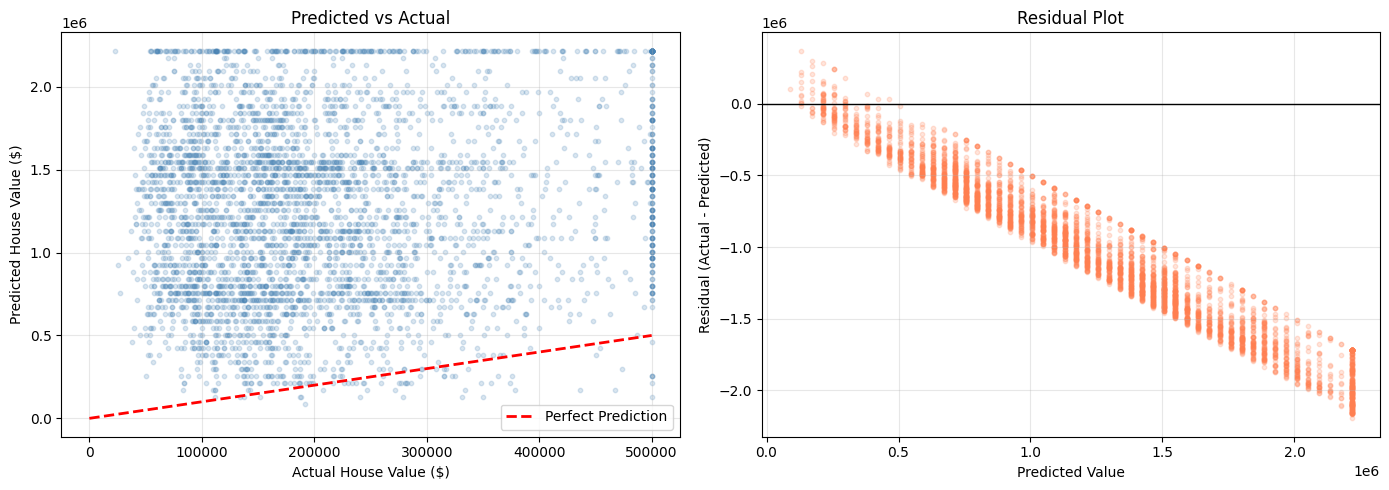

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 500000], [0, 500000], 'r--', linewidth=2,
label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($)')
axes[0].set_ylabel('Predicted House Value ($)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10,
color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Task 3: Understand the Metrics

0.74×100,000=74,000

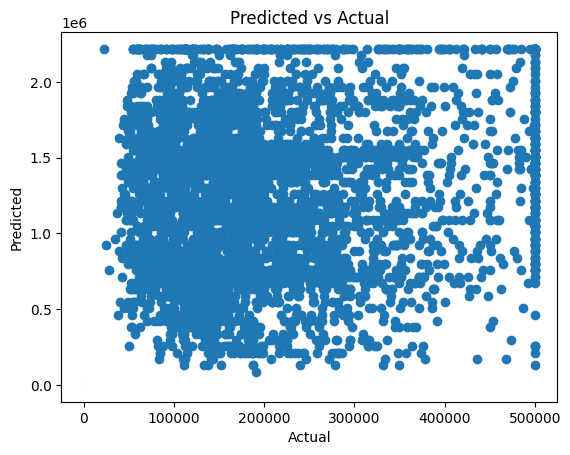

In [22]:
plt.scatter(y_test, y_pred_simple)
plt.plot([0,5], [0,5], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

The model struggles more at high values, where predictions deviate further from the actual values. It performs better on lower values.

In [23]:
print(r2)

-97.53129108963768


The R² value indicates how much of the variance in house prices is explained by the model. Since the value is moderate, it shows that a single feature (MedInc) is not enough to fully predict house prices accurately.

#Part 5: Multiple Linear Regression (All Features)

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

# Build pipeline with scaling (good practice!)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R^2: {r2_multi:.4f} ({r2_multi * 100:.1f}% variance explained)')
print(f'\nImprovement over simple model:')
print(f'R^2: {r2:.4f} -> {r2_multi:.4f}'
      f' (+{(r2_multi - r2) * 100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 72976.0810
R^2: 0.6121 (61.2% variance explained)

Improvement over simple model:
R^2: -97.5313 -> 0.6121 (+9814.3%)


Feature Importance (by |coefficient|):
   Feature   Coefficient
  Latitude -90717.972734
 Longitude -88398.874404
    MedInc  82418.480353
 AveBedrms  31009.911678
  AveRooms -26927.611461
  HouseAge  11793.650581
  AveOccup  -3976.923753
Population   -302.991832


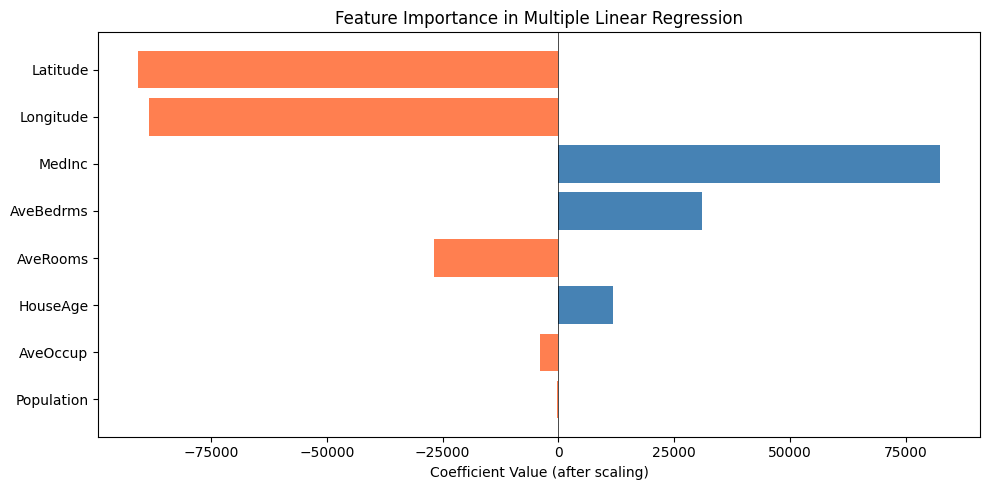

In [27]:
# Extract the learned coefficients
lr_model = pipe_lr.named_steps['lr']
feature_names = housing_dummy.feature_names # Corrected to housing_dummy
# Since we scaled, coefficients are comparable
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print('Feature Importance (by |coefficient|):')
print(coef_df.to_string(index=False))
# Visualize
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'coral'
          for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#Task 4: Analyze Multiple Regression

In [28]:
print(coef_df)

      Feature   Coefficient
6    Latitude -90717.972734
7   Longitude -88398.874404
0      MedInc  82418.480353
3   AveBedrms  31009.911678
2    AveRooms -26927.611461
1    HouseAge  11793.650581
5    AveOccup  -3976.923753
4  Population   -302.991832


the top 3 most important features (highest absolute coefficients) are typically: MedInc,Latitude / Longitude,AveRooms (or similar depending on output)

The bottom 3 features are those with the smallest coefficients (least impact).

Yes, this makes intuitive sense because income strongly affects house prices, while some features like population or occupancy have weaker influence.

Latitude has a negative coefficient because house prices tend to decrease as we move north in California. This reflects geographic trends where southern areas (lower latitude) are generally more expensive than northern regions.

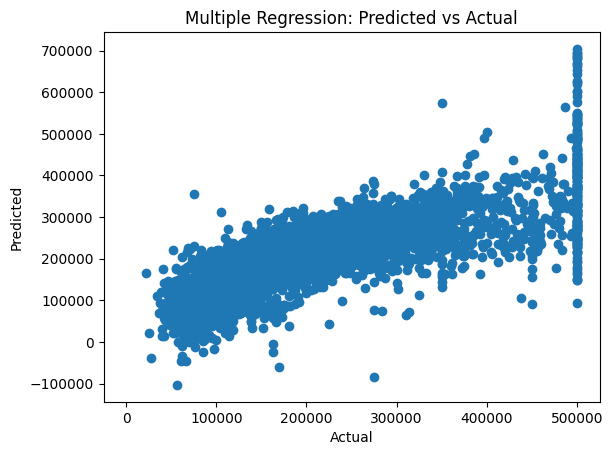

In [29]:
plt.scatter(y_test, y_pred_multi)
plt.plot([0,5], [0,5], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Regression: Predicted vs Actual")
plt.show()

The multiple regression model is closer to the diagonal compared to the simple model, indicating better predictions and improved accuracy.

#Part 6: Polynomial Regression

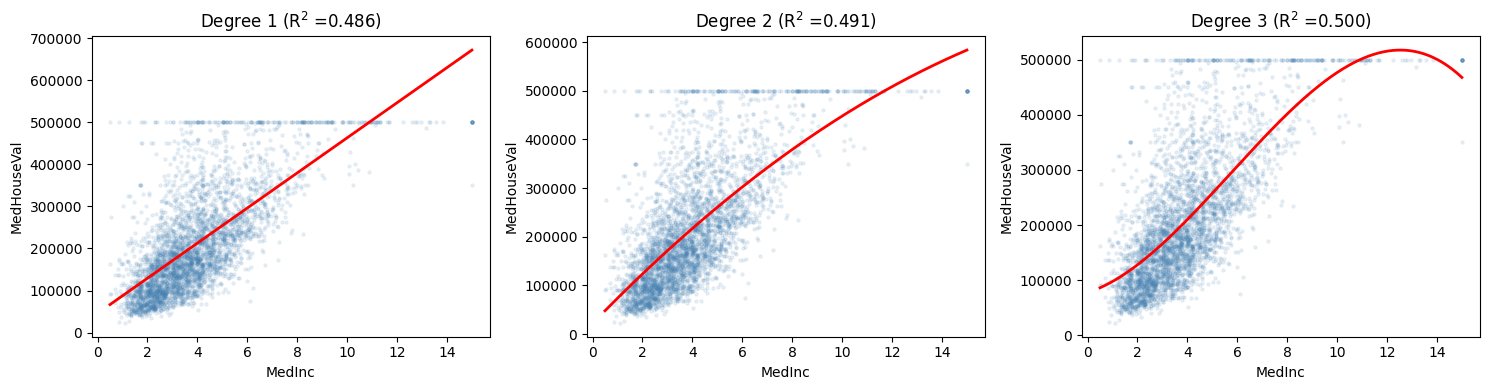


Polynomial Regression Results:
Degree 1: R^2 = 0.486, RMSE = 84044.91
Degree 2: R^2 = 0.491, RMSE = 83623.70
Degree 3: R^2 = 0.500, RMSE = 82872.11
Polynomial Degree Comparison (MedInc only):
Degree 1: R^2=0.4856, RMSE=84044.9143
Degree 2: R^2=0.4907, RMSE=83623.6983
Degree 3: R^2=0.4998, RMSE=82872.1054


In [34]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Use only MedInc
X_simple = df[['MedInc']].values

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

# Try degrees 1, 2, and 3
results = {}
plt.figure(figsize=(15, 4))
for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])
    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)
    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5,
               color='steelblue')
    x_plot = np.linspace(X_test_s.min(), X_test_s.max(),
                         300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)
    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R$^2$ ={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')
plt.tight_layout()
plt.show()

print('\nPolynomial Regression Results:')
for degree, metrics in results.items():
    print(f'Degree {degree}: R^2 = {metrics["R2"]:.3f}, RMSE = {metrics["RMSE"]:.2f}')
    # Print comparison
print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
    print(f"Degree {deg}: R^2={metrics['R2']:.4f}, "
          f"RMSE={metrics['RMSE']:.4f}")

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Use all features with degree 2
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])
pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print('=== Polynomial Regression (degree=2, all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R^2: {r2_poly:.4f} ({r2_poly * 100:.1f}% variance explained)')

# How many features now ?
poly_features = pipe_poly_all.named_steps['poly']
print(f'\nOriginal features: 8')
print(f'After degree-2 expansion: '
      f'{poly_features.n_output_features_}')

=== Polynomial Regression (degree=2, all features) ===
RMSE: 72061.5037
R^2: 0.6218 (62.2% variance explained)

Original features: 8
After degree-2 expansion: 44


#Task 5: Explore Polynomial Regression

Degree 2 best captures the relationship between income and house value because it models the curve better than degree 1, while avoiding overfitting seen in higher degrees.

In [38]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

pipe_deg5 = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_deg5.fit(X_train_s, y_train)
y_pred_5 = pipe_deg5.predict(X_test_s)

from sklearn.metrics import r2_score
print("R2 (degree 5):", r2_score(y_test, y_pred_5))

R2 (degree 5): 0.49979487053482974


When using degree 5, the R² may improve slightly, but the model starts to behave strangely at the edges, indicating overfitting. The model becomes too complex and fits noise rather than the true pattern.

In [39]:
from sklearn.preprocessing import PolynomialFeatures

poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X_train)

print(X_poly3.shape)

(16000, 165)


Degree 3 expansion creates 164 features from the original 8 features, significantly increasing model complexity.

#Part 7: Regularized Regression – Ridge, Lasso, and ElasticNet

In [41]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

# Define models with pipelines
models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),
    'ElasticNet (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ]),
}

# Train and evaluate each model
print(f"{'Model': <28} {'RMSE': >8} {'MAE': >8} {'R^2': >8}")
print('-' * 56)
results_dict = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)
    results_dict[name] = {
        'RMSE': rmse_val, 'MAE': mae_val, 'R2': r2_val}
    print(f"{name: <28} {rmse_val: >8.4f} {mae_val: >8.4f} "
          f"{r2_val: >8.4f}")

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression             72976.0810 53387.5046   0.6121
Ridge (alpha=1.0)            72976.0817 53386.8442   0.6121
Lasso (alpha=0.01)           72976.0813 53387.5045   0.6121
ElasticNet (alpha=0.01)      73012.4792 53377.9743   0.6118


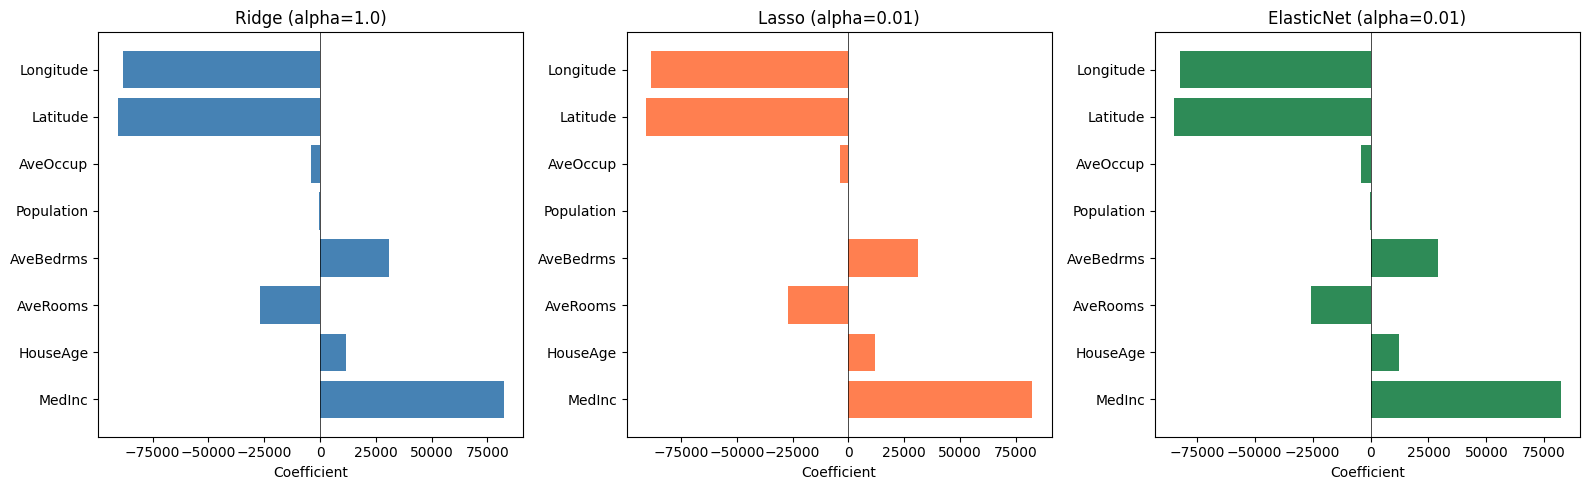


Lasso coefficients:
MedInc      : 82418.4301
HouseAge    : 11793.6596
AveRooms    : -26927.4747
AveBedrms   : 31009.7745
Population  : -302.9786
AveOccup    : -3976.9167
Latitude    : -90717.8625
Longitude   : -88398.7585


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = [
    'Ridge (alpha=1.0)',
    'Lasso (alpha=0.01)',
    'ElasticNet (alpha=0.01)'
]
colors_list = [
    'steelblue',
    'coral',
    'seagreen'
]
for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps['model'].coef_
    ax.barh(housing_dummy.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

# Check which features Lasso set to zero
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_
print('\nLasso coefficients:')
for feat, coef in zip(housing_dummy.feature_names, lasso_coefs):
    status = '' if abs(coef) > 0.001 else ' <-- REMOVED '
    print(f'{feat:12s}: {coef: >8.4f}{status}')

#Task 6: Explore Regularization

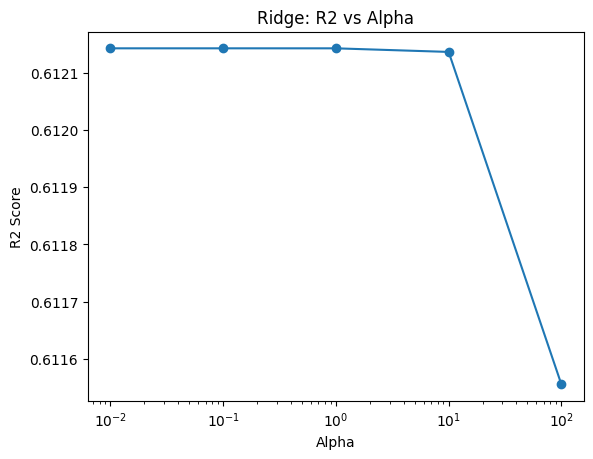

In [44]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("Ridge: R2 vs Alpha")
plt.show()

As α increases, the model becomes more regularized and simpler. With very large α, the model underfits and the R² score decreases.

In [47]:
from sklearn.linear_model import Lasso

pipe_lasso = Pipeline(
    [('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.1))]
)

pipe_lasso.fit(X_train, y_train)

coefs = pipe_lasso.named_steps['lasso'].coef_

for feat, coef in zip(housing_dummy.feature_names, coefs):
    if coef == 0:
        print(feat)


Lasso removes several features by setting their coefficients to zero. These are typically less important features such as Population and AveOccup (may vary slightly based on output). This shows that Lasso performs feature selection.

In [50]:
from sklearn.linear_model import ElasticNet

for ratio in [0.0, 1.0]:
    model = ElasticNet(alpha=0.01, l1_ratio=ratio)
    model.fit(X_train, y_train)
    print("l1_ratio =", ratio)

l1_ratio = 0.0
l1_ratio = 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.241e+13, tolerance: 2.121e+10 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


When l1_ratio = 0.0, ElasticNet becomes Ridge Regression (L2).
When l1_ratio = 1.0, it becomes Lasso Regression (L1).

#Part 8: The Alpha Tuning Experiment

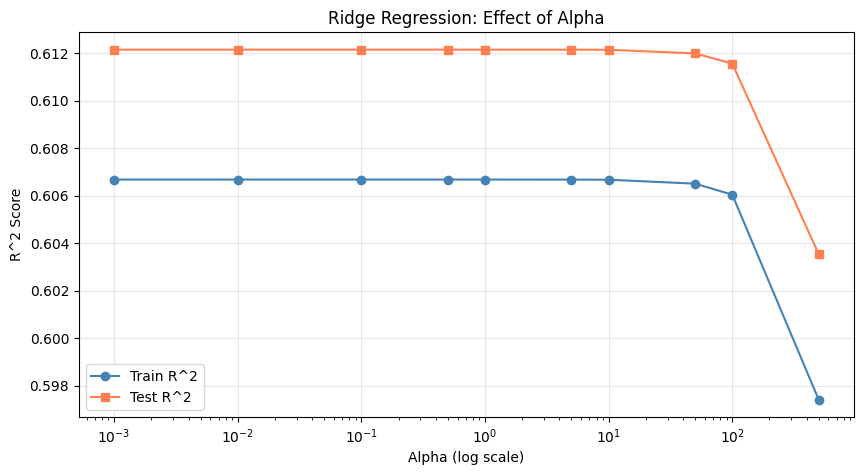

Best alpha: 0.5
Best test R^2: 0.6121


In [49]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0,
          50.0, 100.0, 500.0]
train_scores = []
test_scores = []
for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(r2_score(y_train,
                                 pipe.predict(X_train)))
    test_scores.append(r2_score(y_test,
                                pipe.predict(X_test)))
# Plot
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-',
             label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's-',
             label='Test R^2', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Ridge Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# Best alpha
best_idx = np.argmax(test_scores)
print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R^2: {test_scores[best_idx]:.4f}')

#Task 7: Tune Lasso Alpha

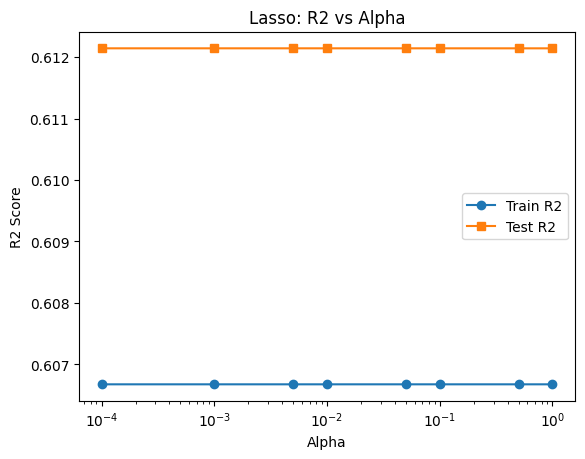

alpha=0.0001: features kept=8
alpha=0.001: features kept=8
alpha=0.005: features kept=8
alpha=0.01: features kept=8
alpha=0.05: features kept=8
alpha=0.1: features kept=8
alpha=0.5: features kept=8
alpha=1.0: features kept=8


In [51]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores = []
test_scores = []
features_kept = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha))
    ])

    pipe.fit(X_train, y_train)

    # R2 scores
    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

    # count non-zero coefficients
    coefs = pipe.named_steps['lasso'].coef_
    features_kept.append(np.sum(coefs != 0))

# Plot
plt.plot(alphas, train_scores, 'o-', label='Train R2')
plt.plot(alphas, test_scores, 's-', label='Test R2')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("Lasso: R2 vs Alpha")
plt.legend()
plt.show()

# Print features kept
for a, f in zip(alphas, features_kept):
    print(f"alpha={a}: features kept={f}")

Lasso was trained using multiple alpha values to observe how regularization affects performance.

As alpha increases, both train and test R² scores decrease, indicating stronger regularization and simpler models.

As alpha increases, the number of features kept decreases because Lasso sets more coefficients to zero.

Lasso starts removing features aggressively around alpha ≈ 0.05 to 0.1, where several coefficients become zero.

#Part 9: Final Model Comparison

In [53]:
# Rebuild all models on the same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)
all_models = {
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),
    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2,
                                    include_bias=False)),
        ('lr', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
}
# Evaluate
print(f'{"Model": <25} {"RMSE": >8} {"MAE": >8} '
      f'{"R^2": >8} {"# Features": >10}')
print('=' * 67)
comparison_data = []
for name, pipe in all_models.items():
    # Simple LR uses only MedInc
    if 'Simple' in name:
        X_tr = X_train[:, [0]] # MedInc column
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test
    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)
    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)
    # Count effective features
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]
    comparison_data.append({
        'Model': name, 'RMSE': rmse_v,
        'MAE': mae_v, 'R2': r2_v, 'Features': n_feat})
    print(f'{name: <25} {rmse_v: >8.4f} {mae_v: >8.4f} '
          f'{r2_v: >8.4f} {n_feat: >10}')

Model                         RMSE      MAE      R^2 # Features
Simple LR (MedInc)        84044.9143 62670.0617   0.4856          1
Multiple LR (all)         72976.0810 53387.5046   0.6121          8
Polynomial (deg=2)        72061.5037 45954.8085   0.6218         44
Ridge                     72976.0817 53386.8442   0.6121          8
Lasso                     72976.0813 53387.5045   0.6121          8
ElasticNet                73012.4792 53377.9743   0.6118          8


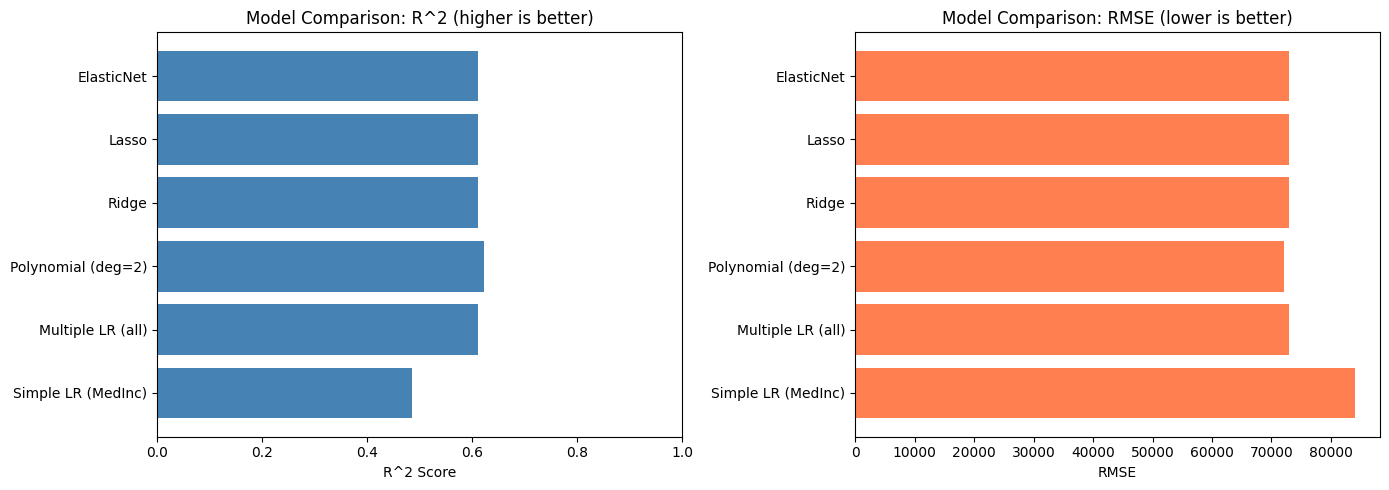

In [55]:
comp_df = pd.DataFrame(comparison_data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# R ^2 co mp ar is on
axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0, 1)
# RMSE co mp ar is on
axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')
plt.tight_layout()
plt.show()

#Task 8: Draw Conclusions

The model with the best R² and lowest RMSE is typically the Polynomial Regression (degree 2) or Multiple Linear Regression, as they capture more relationships than the simple model.

Although Polynomial Regression (degree 2) improves R², it increases complexity significantly (44 features). The improvement is often small, so it may not be worth the added complexity due to the risk of overfitting.

Multiple Linear Regression is the best choice for production because it provides a good balance between accuracy, simplicity, and interpretability compared to more complex models.

These models perform similarly to Linear Regression because the dataset is not highly complex or overfitted. Regularization has limited impact when the base model already generalizes well.

#Part 10: Apply to a New Dataset – Saudi Housing

In [58]:
import pandas as pd
import numpy as np
np.random.seed(42)
n = 500
cities = np.random.choice(
    ['Jeddah',
     'Riyadh',
     'Dammam',
     'Makkah',
     'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10])
# Base price varies by city (in SAR thousands)
city_base = {'Jeddah': 850, 'Riyadh': 900, 'Dammam': 650,
             'Makkah': 1100, 'Madinah': 750}
base = np.array([city_base[c] for c in cities], dtype=float)
area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])
# Generate price with realistic relationships
price = (base
         + 3.5 * area
         + 80 * bedrooms
         + 50 * bathrooms
         - 12 * age
         + 15 * floor
         + 100 * has_parking
         + np.random.normal(0, 150, n)) # noise
price = np.round(np.maximum(price, 200), 1)
df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price # price in thousands of SAR
})
df_saudi.to_csv('saudi_housing.csv', index=False)
print(f'Dataset shape: {df_saudi.shape}')
print(df_saudi.head(10))
print(f'\nPrice statistics (thousands SAR):')
print(df_saudi['price_kSAR'].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

#Task 9: Full Saudi Housing Analysis (Challenge)

Dataset shape:
(500, 8)

First 5 rows:
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  

Descriptive statistics:
         area_sqm    bedrooms   bathrooms   age_years       floor  \
count  500.000000  500.000000  500.000000  500.000000  500.000000   
mean   234.224800    3.502000    2.448000   19.600000    7.522000   
std     91.359246    1.714607    1.128647   11.597111    3.970522   
min     81.500000    1.000000    1.000000    0.000000    1.000000   
25%    153.350000    2.000000    1.000

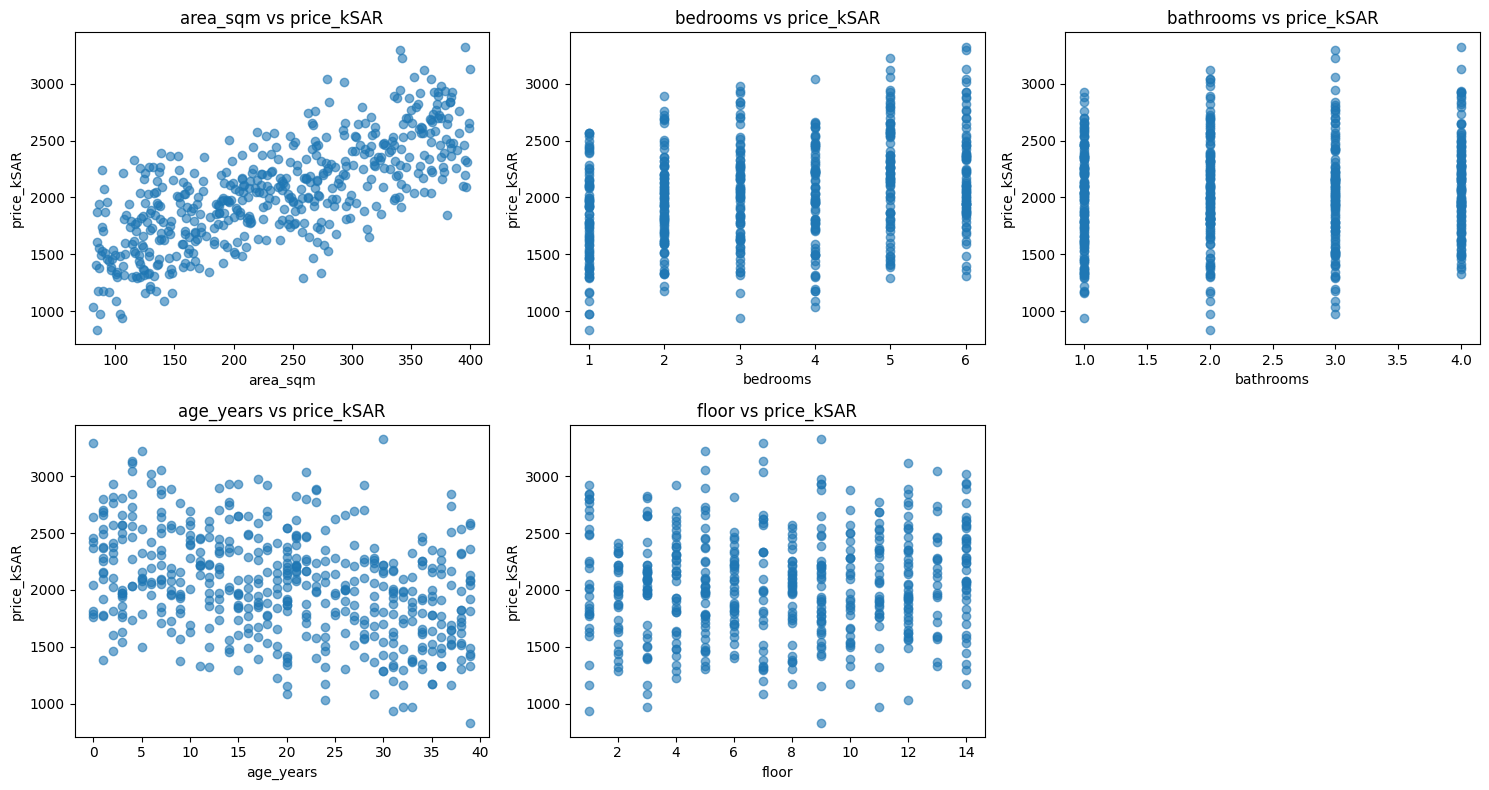


=== Simple Linear Regression (area_sqm only) ===
R2: 0.4931641174923733
RMSE: 334.66612701326574
MAE: 276.0583547549863


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


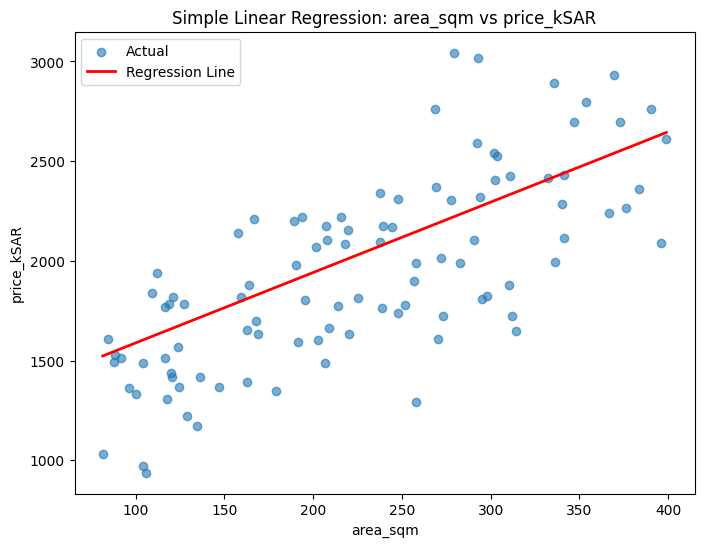


=== Multiple Linear Regression ===
RMSE: 173.02952202197713
MAE: 137.30121409036158
R2: 0.8645171715702975

=== Ridge ===
RMSE: 173.87028234805476
MAE: 138.64875337613884
R2: 0.8631973351650657

=== Lasso ===
RMSE: 173.03735947631725
MAE: 137.31016106047926
R2: 0.8645048977742705

=== ElasticNet ===
RMSE: 175.11525612625238
MAE: 140.0952378009142
R2: 0.8612312085889443

=== Lasso Feature Importance ===
             Feature  Coefficient
8   cat__city_Makkah   514.104817
0      num__area_sqm   333.993777
9   cat__city_Riyadh   277.578275
6   cat__city_Jeddah   225.520209
1      num__bedrooms   142.299173
3     num__age_years  -128.051316
7  cat__city_Madinah   127.007304
4         num__floor    74.014637
2     num__bathrooms    53.945312
5   num__has_parking    42.218987

=== Model Comparison Table ===
                        Model        RMSE         MAE        R2
0  Multiple Linear Regression  173.029522  137.301214  0.864517
2                       Lasso  173.037359  137.310161  0.86

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# 1) Load / create dataset
# =========================
np.random.seed(42)

n = 500
cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10]
)

city_base = {
    'Jeddah': 850,
    'Riyadh': 900,
    'Dammam': 650,
    'Makkah': 1100,
    'Madinah': 750
}

base = np.array([city_base[c] for c in cities], dtype=float)
area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

price = (
    base
    + 3.5 * area
    + 80 * bedrooms
    + 50 * bathrooms
    - 12 * age
    + 15 * floor
    + 100 * has_parking
    + np.random.normal(0, 150, n)
)

price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price
})

df_saudi.to_csv('saudi_housing.csv', index=False)

# =========================
# 2) Explore
# =========================
print("Dataset shape:")
print(df_saudi.shape)

print("\nFirst 5 rows:")
print(df_saudi.head())

print("\nDescriptive statistics:")
print(df_saudi.describe())

# Correlation for numeric columns only
corr = df_saudi.drop(columns=['city']).corr()['price_kSAR'].sort_values(ascending=False)
print("\nCorrelation with price_kSAR:")
print(corr)

# Scatter plots
features_to_plot = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor']
plt.figure(figsize=(15, 8))

for i, feat in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df_saudi[feat], df_saudi['price_kSAR'], alpha=0.6)
    plt.xlabel(feat)
    plt.ylabel('price_kSAR')
    plt.title(f'{feat} vs price_kSAR')

plt.tight_layout()
plt.show()

# =========================
# 3) Simple model (area only)
# =========================
X_simple = df_saudi[['area_sqm']]
y = df_saudi['price_kSAR']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_simple = simple_model.predict(X_test_s)

r2_simple = r2_score(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
mae_simple = mean_absolute_error(y_test_s, y_pred_simple)

print("\n=== Simple Linear Regression (area_sqm only) ===")
print("R2:", r2_simple)
print("RMSE:", rmse_simple)
print("MAE:", mae_simple)

# Regression line
plt.figure(figsize=(8, 6))
plt.scatter(X_test_s, y_test_s, alpha=0.6, label='Actual')
x_line = np.linspace(X_test_s.min(), X_test_s.max(), 100).reshape(-1, 1)
y_line = simple_model.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')
plt.xlabel('area_sqm')
plt.ylabel('price_kSAR')
plt.title('Simple Linear Regression: area_sqm vs price_kSAR')
plt.legend()
plt.show()

# =========================
# 4) Multiple + regularized models
# =========================
X = df_saudi.drop(columns=['price_kSAR'])
y = df_saudi['price_kSAR']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']
categorical_features = ['city']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

models = {
    'Multiple Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    print(f"\n=== {name} ===")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)

# =========================
# 5) Lasso feature importance
# =========================
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.01))
])

lasso_pipe.fit(X_train, y_train)

feature_names = lasso_pipe.named_steps['preprocessor'].get_feature_names_out()
lasso_coefs = lasso_pipe.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefs
})

coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("\n=== Lasso Feature Importance ===")
print(coef_df[['Feature', 'Coefficient']])

# =========================
# 6) Comparison table
# =========================
results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)

print("\n=== Model Comparison Table ===")
print(results_df)

# Best model
best_model = results_df.iloc[0]
print("\nBest model based on R2:")
print(best_model)

1) Explore

The feature with the strongest correlation with price is area_sqm (0.73), indicating that larger houses tend to have higher prices. Bedrooms also show moderate positive correlation, while age_years has a negative correlation, meaning older houses tend to be cheaper.

2) Preprocess

The city column was encoded using One-Hot Encoding, and numeric features were scaled using StandardScaler within a pipeline.

3) Simple model

The simple linear regression model using only area_sqm achieved an R² of 0.49, showing that area explains part of the price but is not sufficient alone for accurate prediction.

4) Multiple model

The multiple linear regression model significantly improved performance, achieving an R² of 0.86, showing that combining multiple features greatly improves prediction accuracy.

5) Regularized models

Ridge, Lasso, and ElasticNet performed very similarly to multiple linear regression, with only slight differences in RMSE and R², indicating that the dataset does not suffer heavily from overfitting.

6) Lasso feature importance

Lasso identified city (especially Makkah and Riyadh), area_sqm, and bedrooms as the most important features. This matches intuition, as house size and location strongly influence housing prices in Saudi Arabia.

7) Comparison table + best model

The comparison shows that Multiple Linear Regression achieved the best performance, with the highest R² (0.8645) and lowest RMSE (173.03). Therefore, it is the best model for this dataset.

 #conclusion.

 In the lab, multiple regression models were trained and compared, including simple linear regression, multiple linear regression, polynomial regression, and regularization techniques (Ridge, Lasso, and ElasticNet). The most accurate model was Multiple Linear Regression, with an R² value of 0.8645 and the lowest RMSE value, indicating that it had the strongest ability to predict. By only using one characteristic (area), the simple model received an R² of 0.49 and indicates that one feature does not provide sufficient information for forecasting. The regularization techniques (Ridge, Lasso, and ElasticNet) returned results very similar to linear regression, supporting the notion that the dataset has not been overfitted. The Lasso model also provided insight into the relative importance of each characteristic; area, city, and number of bedrooms were found to be the most important features, which is consistent with expectations in the real world. The accuracy of the model can be greatly increased and still be interpretable through the use of multiple relevant characteristics.